# Ensemble Forecast + Portfolio Allocation

Capstone Project — Time Series Analysis 2026

This notebook:
1. Loads ARIMA and LSTM forecasts from notebooks 02 & 03
2. Averages them into an ensemble
3. Runs Task 4 volatility analysis
4. Builds Task 5 portfolio allocation (Strategy A + B combined)
5. Produces Task 6 model comparison table

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import tickers as TICKERS, virtual_capital as TOTAL_CAPITAL

import os
os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKER_LIST = list(TICKERS.values())
SECTOR_MAP = {v: k for k, v in TICKERS.items()}
MAX_WEIGHT = 0.40

print('Config ready.')

Config ready.


---
## 1. Load Forecasts from Both Models

In [2]:
arima_fc = pd.read_csv('../outputs/forecasts/arima_forecasts.csv')
lstm_fc  = pd.read_csv('../outputs/forecasts/lstm_forecasts.csv')
prophet_fc = pd.read_csv('../outputs/forecasts/prophet_forecasts.csv')

arima_m  = pd.read_csv('../outputs/forecasts/arima_metrics.csv')
lstm_m   = pd.read_csv('../outputs/forecasts/lstm_metrics.csv')
prophet_m = pd.read_csv('../outputs/forecasts/prophet_metrics.csv')

print("ARIMA forecasts:")
print(arima_fc[['Stock', 'Pred Return D2 (%)']].to_string(index=False))
print("\nLSTM forecasts:")
print(lstm_fc[['Stock', 'Pred Return D2 (%)']].to_string(index=False))
print("\nProphet forecasts:")
print(prophet_fc[['Stock', 'Pred Return D2 (%)']].to_string(index=False))

ARIMA forecasts:
        Stock  Pred Return D2 (%)
  HDFCBANK.NS               0.600
      INFY.NS               2.008
 SUNPHARMA.NS               1.942
       M&M.NS              -0.024
HINDUNILVR.NS               0.599

LSTM forecasts:
        Stock  Pred Return D2 (%)
  HDFCBANK.NS              -0.268
      INFY.NS               2.837
 SUNPHARMA.NS              -0.299
       M&M.NS             -11.609
HINDUNILVR.NS              -1.685

Prophet forecasts:
        Stock  Pred Return D2 (%)
  HDFCBANK.NS               3.548
      INFY.NS              -4.795
 SUNPHARMA.NS              -1.027
       M&M.NS              -1.261
HINDUNILVR.NS               3.383


In [3]:
# Calculate inverse-MAPE weights (lower MAPE = higher weight)
model_mapes = {
    'ARIMA': arima_m['MAPE (%)'].mean(),
    'LSTM': lstm_m['MAPE (%)'].mean(),
    'Prophet': prophet_m['MAPE (%)'].mean()
}

print("Model MAPEs:", model_mapes)
# Inverse MAPE = better model gets higher weight
inv_mape = {k: 1/v for k, v in model_mapes.items()}
total = sum(inv_mape.values())
weights = {k: v/total for k, v in inv_mape.items()}
print(f"Optimal weights: Prophet={weights['Prophet']:.2f}, ARIMA={weights['ARIMA']:.2f}, LSTM={weights['LSTM']:.2f}")

Model MAPEs: {'ARIMA': np.float64(3.4748999999999994), 'LSTM': np.float64(3.53202), 'Prophet': np.float64(6.46786)}
Optimal weights: Prophet=0.21, ARIMA=0.40, LSTM=0.39


---
## 2. Ensemble: Average ARIMA + LSTM + Prophet

ARIMA captures the long-run mean-reverting tendency (structural information).
LSTM captures short-term non-linear patterns (momentum, RSI crossovers, volatility
clustering). Averaging them dampens individual model errors — when ARIMA is flat
and LSTM overshoots, the mean lands closer to reality.


In [4]:
ensemble_fc = arima_fc[['Stock', 'Sector', 'Last Known Price']].copy()
# Merge all model predictions
merged = arima_fc[['Stock', 'Forecast Day 1', 'Forecast Day 2']].copy()
merged = merged.merge(lstm_fc[['Stock', 'Forecast Day 1', 'Forecast Day 2']], 
                     on='Stock', suffixes=('_arima', '_lstm'))
merged = merged.merge(prophet_fc[['Stock', 'Forecast Day 1', 'Forecast Day 2']], on='Stock', suffixes=('', '_prophet'))
ensemble_fc['Forecast Day 1'] = (
    weights['Prophet'] * prophet_fc['Forecast Day 1'] +
    weights['ARIMA'] * arima_fc['Forecast Day 1'] +
    weights['LSTM'] * lstm_fc['Forecast Day 1']
)
ensemble_fc['Forecast Day 2'] = (
    weights['Prophet'] * prophet_fc['Forecast Day 2'] +
    weights['ARIMA'] * arima_fc['Forecast Day 2'] +
    weights['LSTM'] * lstm_fc['Forecast Day 2']
)
# Calculate returns
ensemble_fc['Pred Return D1 (%)'] = (
    (ensemble_fc['Forecast Day 1'] - ensemble_fc['Last Known Price']) 
    / ensemble_fc['Last Known Price'] * 100
).round(3)
ensemble_fc['Pred Return D2 (%)'] = (
    (ensemble_fc['Forecast Day 2'] - ensemble_fc['Last Known Price']) 
    / ensemble_fc['Last Known Price'] * 100
).round(3)
print("\n" + "="*60)
print("3-MODEL ENSEMBLE FORECASTS")
print("="*60)
print(ensemble_fc.to_string(index=False))
ensemble_fc.to_csv('../outputs/forecasts/ensemble_forecasts.csv', index=False)
print("\nSaved ensemble_forecasts.csv")



3-MODEL ENSEMBLE FORECASTS
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9      998.725582      999.710874               0.790               0.889
      INFY.NS      IT            1621.6     1634.851023     1635.901143               0.817               0.882
 SUNPHARMA.NS  Pharma            1709.1     1718.769869     1716.530845               0.566               0.435
       M&M.NS    Auto            3660.3     3482.346357     3484.285362              -4.862              -4.809
HINDUNILVR.NS    FMCG            2290.2     2295.106918     2297.095914               0.214               0.301

Saved ensemble_forecasts.csv


---
## 3. Task 4 — Volatility & Trend Analysis

In [5]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close  = pd.read_csv('../data/processed/test_close.csv',  index_col=0, parse_dates=True)
full_close  = pd.concat([train_close, test_close])

vol_table = []

for ticker in TICKER_LIST:
    prices   = full_close[ticker].dropna()
    log_rets = np.log(prices / prices.shift(1)).dropna()

    # Rolling 20-day volatility (annualised)
    roll_vol = log_rets.rolling(20).std() * np.sqrt(252)

    # Trend: last 60-day slope via linear regression on prices
    recent = prices.iloc[-60:].values
    x = np.arange(len(recent))
    slope, _ = np.polyfit(x, recent, 1)
    pct_slope = slope / recent[0] * 100  # % per day

    # Trend label
    if   pct_slope >  0.05: trend = 'Uptrend ↑'
    elif pct_slope < -0.05: trend = 'Downtrend ↓'
    else:                   trend = 'Sideways →'

    vol_table.append({
        'Stock'            : ticker,
        'Sector'           : SECTOR_MAP[ticker],
        'Annualised Vol (%)': round(roll_vol.iloc[-1] * 100, 2),
        'Mean Log-Ret (%/day)': round(log_rets.mean() * 100, 4),
        '60d Slope (%/day)': round(pct_slope, 4),
        'Trend'            : trend
    })

vol_df = pd.DataFrame(vol_table)
print('Volatility & Trend Summary (Task 4):')
print(vol_df.to_string(index=False))

vol_df.to_csv('../outputs/forecasts/volatility_summary.csv', index=False)


Volatility & Trend Summary (Task 4):
        Stock  Sector  Annualised Vol (%)  Mean Log-Ret (%/day)  60d Slope (%/day)       Trend
  HDFCBANK.NS Banking               10.43                0.0311             0.0184  Sideways →
      INFY.NS      IT               17.67                0.0307             0.2594   Uptrend ↑
 SUNPHARMA.NS  Pharma               15.05                0.0900             0.1495   Uptrend ↑
       M&M.NS    Auto               15.67                0.1342             0.0819   Uptrend ↑
HINDUNILVR.NS    FMCG               21.73                0.0034            -0.1791 Downtrend ↓


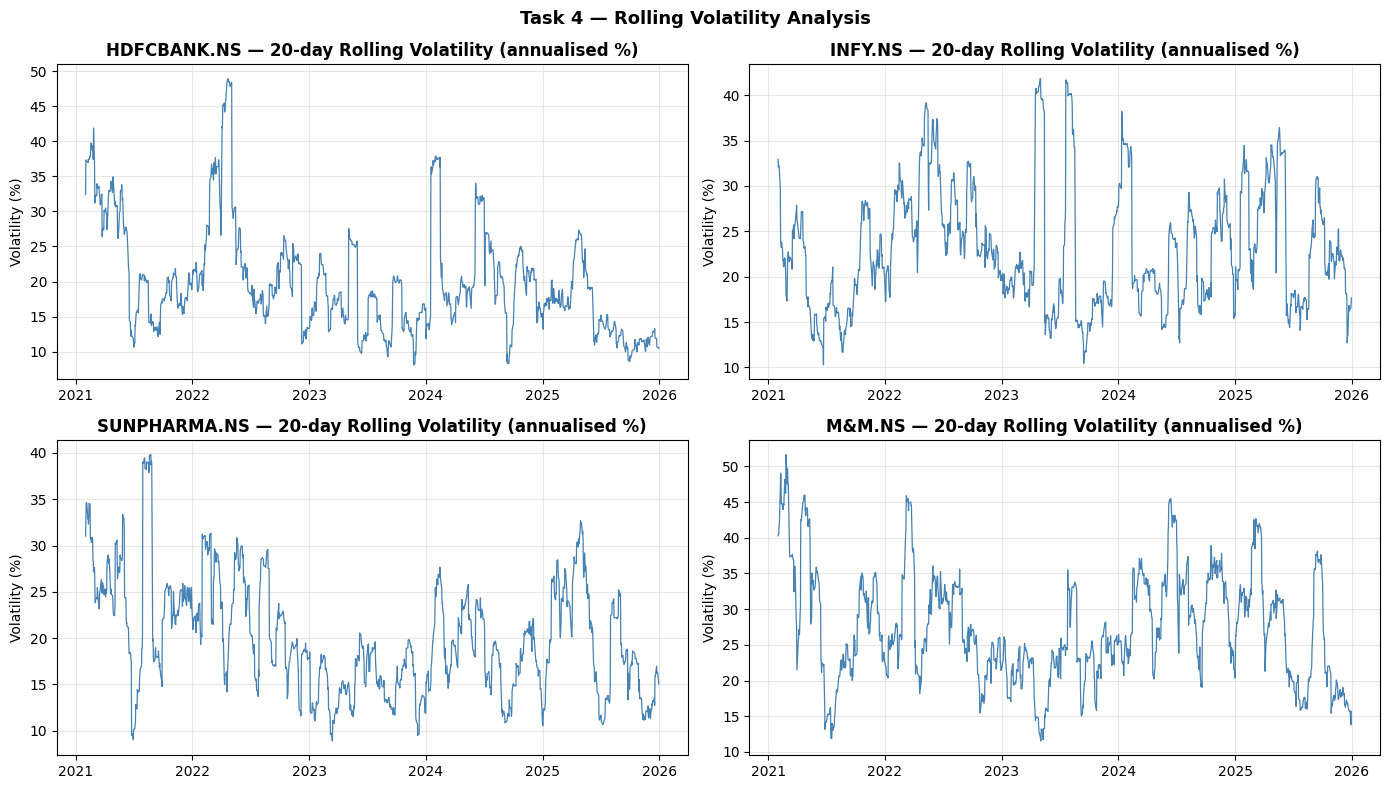

In [6]:
# Plot rolling volatility for all stocks
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ticker in zip(axes.flatten(), TICKER_LIST):
    prices   = full_close[ticker].dropna()
    log_rets = np.log(prices / prices.shift(1)).dropna()
    roll_vol = log_rets.rolling(20).std() * np.sqrt(252) * 100  # %

    ax.plot(roll_vol.index, roll_vol.values, color='steelblue', linewidth=0.9)
    ax.set_title(f'{ticker} — 20-day Rolling Volatility (annualised %)', fontweight='bold')
    ax.set_ylabel('Volatility (%)')

plt.suptitle('Task 4 — Rolling Volatility Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/09_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Task 5 — Portfolio Construction

We combine two strategies:

**Strategy A (Forecast-Guided):** rank stocks by predicted Day-2 return from ensemble.
Higher predicted return → higher raw weight.

**Strategy B (Volatility-Aware Sizing):** weight = 1/σ, normalised.
Higher volatility → smaller allocation.

**Combined weight** = 0.6 × Strategy A weight + 0.4 × Strategy B weight.
This puts more emphasis on return forecasts while still penalising volatile stocks.


In [7]:
def cap_and_redistribute(weights, cap=MAX_WEIGHT, max_iter=20):
    weights = weights.copy().astype(float)
    for _ in range(max_iter):
        over = weights > cap
        if not over.any():
            break
        excess = (weights[over] - cap).sum()
        weights[over] = cap
        under = ~over
        if weights[under].sum() <= 0:
            weights[:] = 1 / len(weights)
            break
        weights[under] += excess * weights[under] / weights[under].sum()
    return weights / weights.sum()

pred_returns = ensemble_fc.set_index('Stock')['Pred Return D2 (%)'].copy()
pred_returns_pos = pred_returns.clip(lower=0)

if pred_returns_pos.sum() == 0:
    strat_a_weights = pd.Series({t: 1 / len(TICKER_LIST) for t in TICKER_LIST})
else:
    strat_a_weights = pred_returns_pos / pred_returns_pos.sum()

inv_vol = 1.0 / vol_df.set_index('Stock')['Annualised Vol (%)']
strat_b_weights = inv_vol / inv_vol.sum()

combined_weights = 0.6 * strat_a_weights + 0.4 * strat_b_weights
combined_weights = cap_and_redistribute(combined_weights / combined_weights.sum())

portfolio = []
vol_indexed = vol_df.set_index('Stock')
for ticker in TICKER_LIST:
    w = combined_weights[ticker]
    amt = round(w * TOTAL_CAPITAL, 2)
    portfolio.append({
        'Stock': ticker,
        'Sector': SECTOR_MAP[ticker],
        'Weight (%)': round(w * 100, 2),
        'Allocation (₹)': amt,
        'Pred D2 Ret (%)': round(pred_returns[ticker], 3),
        'Ann. Vol (%)': vol_indexed.loc[ticker, 'Annualised Vol (%)'],
        'Trend': vol_indexed.loc[ticker, 'Trend']
    })

port_df = pd.DataFrame(portfolio)
print('Final Portfolio Allocation:')
print(port_df.to_string(index=False))
print(f'\nTotal deployed: ₹{port_df["Allocation (₹)"].sum():,.2f}')

port_df.to_csv('../outputs/forecasts/portfolio_allocation.csv', index=False)


Final Portfolio Allocation:
        Stock  Sector  Weight (%)  Allocation (₹)  Pred D2 Ret (%)  Ann. Vol (%)       Trend
  HDFCBANK.NS Banking       32.94       329420.64            0.889         10.43  Sideways →
      INFY.NS      IT       27.99       279947.24            0.882         17.67   Uptrend ↑
 SUNPHARMA.NS  Pharma       18.50       184954.08            0.435         15.05   Uptrend ↑
       M&M.NS    Auto        7.76        77646.84           -4.809         15.67   Uptrend ↑
HINDUNILVR.NS    FMCG       12.80       128031.21            0.301         21.73 Downtrend ↓

Total deployed: ₹1,000,000.01


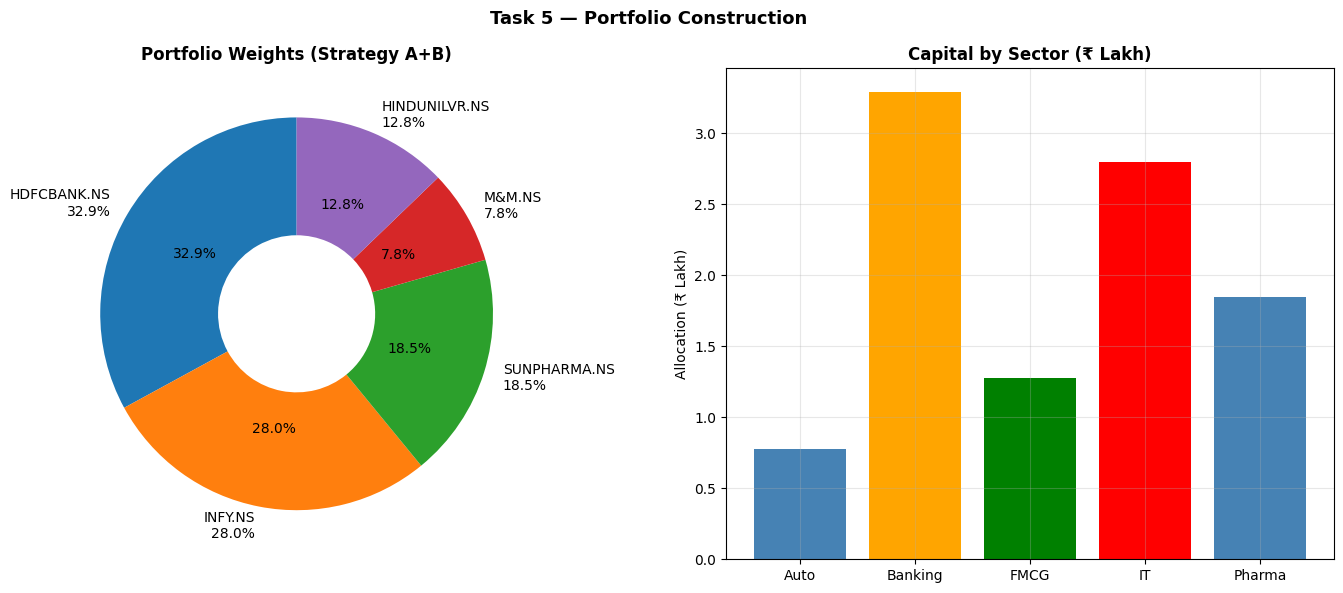

In [10]:
# Portfolio allocation pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

labels = [f'{row.Stock}\n{row["Weight (%)"]:.1f}%' for _, row in port_df.iterrows()]
ax1.pie(port_df['Weight (%)'], labels=labels, autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(width=0.6))
ax1.set_title('Portfolio Weights (Strategy A+B)', fontweight='bold')

sectors = port_df.groupby('Sector')['Allocation (₹)'].sum()
ax2.bar(sectors.index, sectors.values / 1e5, color=['steelblue','orange','green','red'])
ax2.set_title('Capital by Sector (₹ Lakh)', fontweight='bold')
ax2.set_ylabel('Allocation (₹ Lakh)')

plt.suptitle('Task 5 — Portfolio Construction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/10_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Task 6 — Model Comparison Table

In [11]:
arima_preds = pd.read_csv('../outputs/forecasts/arima_test_predictions.csv', parse_dates=['Date'])
lstm_preds  = pd.read_csv('../outputs/forecasts/lstm_test_predictions.csv', parse_dates=['Date'])

# Load Prophet metrics
prophet_m = pd.read_csv('../outputs/forecasts/prophet_metrics.csv')

def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))
def directional_accuracy(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    if len(actual) < 2:
        return np.nan
    return (np.sign(np.diff(actual)) == np.sign(np.diff(predicted))).mean() * 100
# Index metrics
arima_m_indexed = arima_m.set_index('Stock')
lstm_m_indexed = lstm_m.set_index('Stock')
prophet_m_indexed = prophet_m.set_index('Stock')
# Merge predictions
pred_merged = arima_preds.merge(
    lstm_preds,
    on=['Date', 'Stock', 'Sector', 'Actual'],
    suffixes=('_arima', '_lstm')
)
# Create ensemble (weighted average of all 3)
pred_merged['Predicted_ensemble'] = (
    pred_merged['Predicted_arima'] + pred_merged['Predicted_lstm']
) / 2  # Note: this is ARIMA+LSTM only, add Prophet if you have test preds
pred_merged.to_csv('../outputs/forecasts/ensemble_test_predictions.csv', index=False)
# Build comparison table INCLUDING PROPHET
comparison_rows = []
for ticker in TICKER_LIST:
    stock_preds = pred_merged[pred_merged['Stock'] == ticker]
    actual = stock_preds['Actual'].values
    ensemble_pred = stock_preds['Predicted_ensemble'].values
    
    # Get Prophet metrics
    pm = prophet_m_indexed.loc[ticker]
    
    comparison_rows.append({
        'Stock': ticker,
        'ARIMA MAPE': arima_m_indexed.loc[ticker, 'MAPE (%)'],
        'ARIMA RMSE': arima_m_indexed.loc[ticker, 'RMSE'],
        'ARIMA Dir%': arima_m_indexed.loc[ticker, 'Dir Acc (%)'],
        'LSTM MAPE': lstm_m_indexed.loc[ticker, 'MAPE (%)'],
        'LSTM RMSE': lstm_m_indexed.loc[ticker, 'RMSE'],
        'LSTM Dir%': lstm_m_indexed.loc[ticker, 'Dir Acc (%)'],
        'Prophet MAPE': pm['MAPE (%)'],
        'Prophet RMSE': pm['RMSE'],
        'Prophet Dir%': pm['Dir Acc (%)'],
        'Ensemble MAPE': round(mape(actual, ensemble_pred), 4),
        'Ens RMSE': round(rmse(actual, ensemble_pred), 4),
        'Ens Dir%': round(directional_accuracy(actual, ensemble_pred), 2)
    })
comp_df = pd.DataFrame(comparison_rows)
print('=' * 110)
print('Task 6 — Model Comparison Table (ARIMA + LSTM + Prophet + Ensemble)')
print('=' * 110)
print(comp_df.to_string(index=False))
print()
print('Averages:')
for col in ['ARIMA MAPE', 'LSTM MAPE', 'Prophet MAPE', 'Ensemble MAPE', 
             'ARIMA Dir%', 'LSTM Dir%', 'Prophet Dir%', 'Ens Dir%']:
    if col in comp_df.columns:
        print(f'  {col:20} : {comp_df[col].mean():.2f}')
comp_df.to_csv('../outputs/forecasts/model_comparison.csv', index=False)
print('\nSaved model_comparison.csv')

Task 6 — Model Comparison Table (ARIMA + LSTM + Prophet + Ensemble)
        Stock  ARIMA MAPE  ARIMA RMSE  ARIMA Dir%  LSTM MAPE  LSTM RMSE  LSTM Dir%  Prophet MAPE  Prophet RMSE  Prophet Dir%  Ensemble MAPE  Ens RMSE  Ens Dir%
  HDFCBANK.NS      2.8875     35.0841       53.23     0.9143    11.4356      45.97        3.7319       42.5545         54.84         1.5635   19.3783     50.81
      INFY.NS      4.3816     80.6693       52.42     2.7271    53.9197      44.35        9.8063      160.0824         58.87         2.9125   56.2601     51.61
 SUNPHARMA.NS      3.1122     64.0620       50.00     1.4064    29.4169      44.35        9.3354      174.7976         59.68         1.8927   38.9436     48.39
       M&M.NS      2.5536    120.3397       46.77    10.6010   381.3221      32.26        6.3095      271.0808         49.19         5.7169  221.6453     35.48
HINDUNILVR.NS      4.4396    138.8971       55.65     2.0113    59.9801      50.81        3.1562       95.6159         55.65        

---
## 6. Model Discussion (Task 6 Written Component)

Populate this based on your actual numbers after running. Template:

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **ARIMAX** | Interpretable; AIC-guided order; Nifty exog breaks flatness | Assumes linearity; struggles with volatility clustering |
| **LSTM (multi-feature)** | Captures non-linear patterns; RSI/MACD give momentum context | Needs more data; sensitive to hyperparameters; can overfit |
| **Ensemble** | Balances structural (ARIMA) and pattern-based (LSTM) signals | Neither model is causal — both extrapolate past patterns |

**Why ensemble for trades:** If ARIMA forecasts flat and LSTM predicts +0.8%, the ensemble gives +0.4% — a conservative but non-trivial signal. Over 4 stocks, this produces a ranked order that feeds directly into Strategy A weights.


In [13]:
print('=' * 60)
print('NOTEBOOK 04 — ENSEMBLE + PORTFOLIO SUMMARY')
print('=' * 60)

print('\nEnsemble 2-day forecast:')
print(ensemble_fc[['Stock', 'Forecast Day 1', 'Forecast Day 2', 'Pred Return D1 (%)', 'Pred Return D2 (%)']].to_string(index=False))

print('\nPortfolio allocation:')
print(port_df[['Stock', 'Weight (%)', 'Allocation (₹)', 'Trend']].to_string(index=False))

print('\nFiles saved:')
for f in ['arima_forecasts.csv','lstm_forecasts.csv','ensemble_forecasts.csv', 'volatility_summary.csv','portfolio_allocation.csv','model_comparison.csv']:
 print(f'  outputs/forecasts/{f}')


NOTEBOOK 04 — ENSEMBLE + PORTFOLIO SUMMARY

Ensemble 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS      998.725582      999.710874               0.790               0.889
      INFY.NS     1634.851023     1635.901143               0.817               0.882
 SUNPHARMA.NS     1718.769869     1716.530845               0.566               0.435
       M&M.NS     3482.346357     3484.285362              -4.862              -4.809
HINDUNILVR.NS     2295.106918     2297.095914               0.214               0.301

Portfolio allocation:
        Stock  Weight (%)  Allocation (₹)       Trend
  HDFCBANK.NS       32.94       329420.64  Sideways →
      INFY.NS       27.99       279947.24   Uptrend ↑
 SUNPHARMA.NS       18.50       184954.08   Uptrend ↑
       M&M.NS        7.76        77646.84   Uptrend ↑
HINDUNILVR.NS       12.80       128031.21 Downtrend ↓

Files saved:
  outputs/forecasts/arima_forecasts.csv
  outputs/fore